In [116]:
%matplotlib inline
import matplotlib.pyplot as plt

In [117]:
import sys
import pathlib
path_app = pathlib.Path('../../src/visualization_app').resolve()
sys.path.append(path_app.as_posix())

import circuit_map_utils
import tab_lap_telemetry
import data_loader

import numpy as np
import plotly.graph_objects as go


In [118]:
session_id = 'Y2025R06S4'
df_laps = data_loader.load_session_laps(int(session_id[1:5]))
df_laps = df_laps[df_laps["session_id"] == session_id]
keep_laps = (
    df_laps[
        df_laps["is_accurate"]
        & df_laps["timing_pit_out"].isna()
        & df_laps["timing_pit_in"].isna()
        & (df_laps["time_lap"] <= 1.07 * df_laps["time_lap"].min())
    ]
    .sort_values(by=["time_lap"])
    [["session_id", "driver_number", "lap_number"]]
    .drop_duplicates()
)
df_position = data_loader.load_telemetry_pos(int(session_id[1:5]), session_id[5:8])
df_position = df_position[df_position['session_id']==session_id]
df_position = df_position.sort_values(by=["driver_number", "lap_number", "timing_from_lap"])
df_position = df_position[
    (df_position['coordinate_x']!=0)
    & (df_position['coordinate_y']!=0)
]

df_telemetry = data_loader.load_telemetry_car(int(session_id[1:5]), session_id[5:8])
df_telemetry = df_telemetry[df_telemetry['session_id']==session_id]
df_telemetry = df_telemetry.sort_values(by=["driver_number", "lap_number", "timing_from_lap"])


In [119]:
keep_laps

,session_id,driver_number,lap_number
13442,Y2025R06S4,1,17
13723,Y2025R06S4,81,9
13463,Y2025R06S4,4,20
13535,Y2025R06S4,12,19
13729,Y2025R06S4,81,15
...,...,...,...
13466,Y2025R06S4,5,2
13509,Y2025R06S4,10,2
13732,Y2025R06S4,87,2
13576,Y2025R06S4,22,2


In [120]:
circuit_map = tab_lap_telemetry.get_circuit_map(session_id=session_id)

In [121]:
aux = keep_laps.sample(n=1)
df_car1, df_pos1 = tab_lap_telemetry.process_data_lap(df_telemetry.merge(aux), df_position.merge(aux), circuit_map)


In [122]:
xx = np.linspace(0, circuit_map['total_distance'].iloc[0], 1001)
yy = np.interp(xx, df_pos1['absolute_distance'], df_pos1['timing_from_lap'])

In [123]:
plot_data = [
    go.Scatter(
        x=df_pos1['absolute_distance'], y=df_pos1['timing_from_lap'],
        mode="markers",
        marker=dict(size=4)
    ),
    go.Scatter(
        x=xx, y=yy,
        mode="lines+markers",
        marker=dict(size=1, color='blue'),
    ),
]
plot_layout = dict()
figure = go.Figure(data=plot_data, layout=plot_layout)
figure.show()

In [124]:
plot_data = [
    go.Scatter(
        x=df_pos1['absolute_distance'], y=df_pos1['timestamp'],
        mode="markers",
        marker=dict(size=8)
    )
]
plot_layout = dict()
figure = go.Figure(data=plot_data, layout=plot_layout)
figure.show()

In [125]:
aux

,session_id,driver_number,lap_number
13451,Y2025R06S4,4,8


In [126]:
s = df_pos1.sort_values(by=['timestamp'])['absolute_distance'].diff()
s[s<0]

Series([], Name: absolute_distance, dtype: float64)

In [127]:
df_pos1[s<0]

,year,session_id,driver_number,lap_number,timestamp,timing_from_session,timing_from_lap,track_status,coordinate_x,coordinate_y,coordinate_z,position_status,idx,absolute_distance,coordinate_x_fit,coordinate_y_fit


In [128]:
plot_data = [
    go.Scatter(
        x=circuit_map['coordinate_x'],
        y=circuit_map['coordinate_y'],
        text=circuit_map['absolute_distance'],
        mode='markers',
        marker=dict(size=1),
    ),
    go.Scatter(
        x=df_pos1['coordinate_x'], y=df_pos1['coordinate_y'],
        mode="markers",
        marker=dict(size=4)
    )
]
plot_layout = dict()
figure = go.Figure(data=plot_data, layout=plot_layout)
figure.show()

In [129]:
df = df_position.merge(keep_laps)
plot_data = [
    go.Scatter(
        x=df['coordinate_x'],
        y=df['coordinate_y'],
        mode='markers',
        marker=dict(size=1),
    ),
    go.Scatter(
        x=circuit_map['coordinate_x'],
        y=circuit_map['coordinate_y'],
        text=circuit_map['absolute_distance'],
        mode='markers',
        marker=dict(size=1),
    ),
]
plot_layout = dict()
figure = go.Figure(data=plot_data, layout=plot_layout)
figure.show()

In [130]:
df_position.merge(keep_laps)

,year,session_id,driver_number,lap_number,timestamp,timing_from_session,timing_from_lap,track_status,coordinate_x,coordinate_y,coordinate_z,position_status
0,2025,Y2025R06S4,1,2,2025-05-03 20:18:34.236000+00:00,1034.209,0.145,1,1957.0,52.0,250.0,OnTrack
1,2025,Y2025R06S4,1,2,2025-05-03 20:18:34.396000+00:00,1034.369,0.305,1,2153.0,-70.0,251.0,OnTrack
2,2025,Y2025R06S4,1,2,2025-05-03 20:18:34.736000+00:00,1034.709,0.645,1,2308.0,-168.0,251.0,OnTrack
3,2025,Y2025R06S4,1,2,2025-05-03 20:18:35.016000+00:00,1034.989,0.925,1,2506.0,-293.0,251.0,OnTrack
4,2025,Y2025R06S4,1,2,2025-05-03 20:18:35.216000+00:00,1035.189,1.125,1,2649.0,-382.0,251.0,OnTrack
...,...,...,...,...,...,...,...,...,...,...,...,...
30949,2025,Y2025R06S4,87,8,2025-05-03 20:31:49.955000+00:00,1829.928,86.820,1,1040.0,513.0,246.0,OnTrack
30950,2025,Y2025R06S4,87,8,2025-05-03 20:31:50.196000+00:00,1830.169,87.061,1,1218.0,452.0,247.0,OnTrack
30951,2025,Y2025R06S4,87,8,2025-05-03 20:31:50.416000+00:00,1830.389,87.281,1,1376.0,386.0,248.0,OnTrack
30952,2025,Y2025R06S4,87,8,2025-05-03 20:31:50.716000+00:00,1830.689,87.581,1,1643.0,247.0,249.0,OnTrack


In [131]:
import pandas as pd

In [132]:
len(df_laps.merge(keep_laps))

99

In [133]:
df_ = df_position.merge(keep_laps)
bounds = df_.groupby(["driver_number", "lap_number"]).agg(
    {"timing_from_lap": "max"}
)
bounds.columns = ["max_time"]
df_fit1 = df_.merge(
    bounds.reset_index(), on=bounds.index.names, how="inner", suffixes=["", "_DROP"]
)


In [134]:
fit_time = df_fit1["timing_from_lap"] / df_fit1["max_time"]
fitting_part1 = {
    c: circuit_map_utils.FourierFitting(50).fit(fit_time, df_fit1[f"coordinate_{c}"])
    for c in ["x", "y", "z"]
}


In [135]:
df_fit2 = pd.DataFrame()
df_fit2["time"] = np.linspace(0, 1, 10001)
for coord, fit_object in fitting_part1.items():
    df_fit2[f"coordinate_{coord}"] = fit_object.predict(df_fit2["time"])
    df_fit2[f"previous_{coord}"] = df_fit2[f"coordinate_{coord}"].shift(1)
df_fit2["distance"] = np.sqrt(
    (df_fit2["coordinate_x"] - df_fit2["previous_x"]) ** 2
    + (df_fit2["coordinate_y"] - df_fit2["previous_y"]) ** 2
)
df_fit2["distance_cumulative"] = df_fit2["distance"].cumsum()


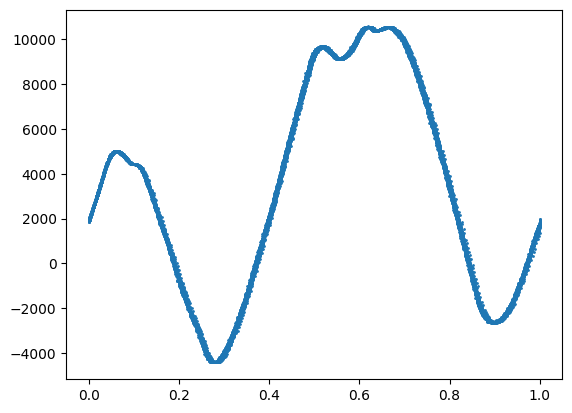

In [136]:
fig, ax = plt.subplots()
ax.scatter(
    df_fit1["timing_from_lap"] / df_fit1["max_time"],
    df_fit1['coordinate_x'],
    s=1,
)


In [137]:
df_fit1[df_fit1['coordinate_x']==0]

,year,session_id,driver_number,lap_number,timestamp,timing_from_session,timing_from_lap,track_status,coordinate_x,coordinate_y,coordinate_z,position_status,max_time


<Axes: ylabel='Frequency'>

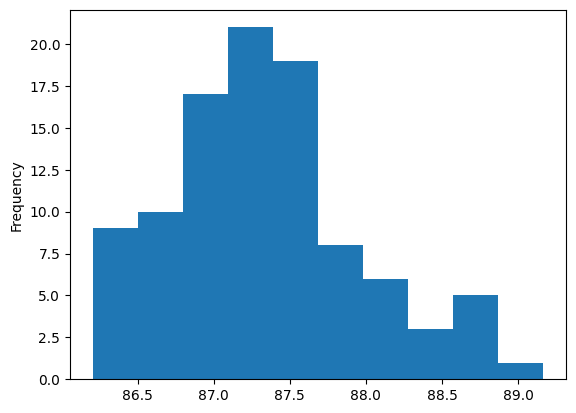

In [138]:
df_laps.merge(keep_laps)['time_lap'].plot.hist()

In [139]:
plot_data = [
    go.Scatter(
        x=df['coordinate_x'],
        y=df['coordinate_y'],
        mode='markers',
        marker=dict(size=1),
    ),
    go.Scatter(
        x=circuit_map['coordinate_x'],
        y=circuit_map['coordinate_y'],
        text=circuit_map['absolute_distance'],
        mode='markers',
        marker=dict(size=1),
    ),
]
plot_layout = dict()
figure = go.Figure(data=plot_data, layout=plot_layout)
figure.show()

In [140]:
keep_laps

,session_id,driver_number,lap_number
13442,Y2025R06S4,1,17
13723,Y2025R06S4,81,9
13463,Y2025R06S4,4,20
13535,Y2025R06S4,12,19
13729,Y2025R06S4,81,15
...,...,...,...
13466,Y2025R06S4,5,2
13509,Y2025R06S4,10,2
13732,Y2025R06S4,87,2
13576,Y2025R06S4,22,2


In [141]:
df_position['coordinate_z'].value_counts()

coordinate_z
243.0    66715
244.0    36544
245.0    20697
246.0    12284
242.0     8756
247.0     6871
249.0     6605
248.0     6424
251.0     3457
241.0     2927
250.0     2605
254.0     2198
252.0     1928
0.0       1895
255.0     1628
253.0     1404
259.0     1395
257.0     1067
260.0      890
273.0      880
258.0      787
238.0      752
261.0      725
256.0      620
237.0      531
239.0      461
240.0      383
267.0      378
271.0      328
272.0      300
263.0      291
262.0      267
265.0      238
270.0      190
269.0      150
274.0      134
264.0      130
266.0      128
268.0      100
Name: count, dtype: int64

In [142]:
df = pd.read_parquet(f'../../data/bronze/telemetry_pos_{session_id}.parquet')

In [143]:
ch = (df['X']!=0) & (df['Y']!=0)
ch.value_counts()

True     194063
False     13037
Name: count, dtype: int64

In [144]:
xx = np.linspace(0, df_pos1['absolute_distance'].max()*1.01, 1001)
interp = np.interp(
    xx, [0] + list(df_pos1['absolute_distance']), [0]+list(df_pos1['timing_from_lap'])
)


In [145]:
plot_data = [
    go.Scatter(
        x=xx, y=interp,
        mode='lines+markers'
    ),
    go.Scatter(
        x=df_pos1['absolute_distance'], y=df_pos1['timing_from_lap'],
        mode='lines+markers', line=dict(color='blue'),
    ),
]
plot_layout = dict()
figure = go.Figure(data=plot_data, layout=plot_layout)
figure.show()

In [146]:
plot_data = [
    go.Scatter(
        x=xx[1:],
        y=np.diff(interp) / np.diff(xx),
        mode='lines+markers'
    ),
    go.Scatter(
        x=df_pos1['absolute_distance'][1:],
        y=np.diff(df_pos1['timing_from_lap']) / np.diff(df_pos1['absolute_distance']),
        mode='lines+markers', line=dict(color='blue'),
    ),
]
plot_layout = dict()
figure = go.Figure(data=plot_data, layout=plot_layout)
figure.show()

## Cubic Spline

In [151]:
np.diff(df_pos1['absolute_distance']).max()

np.float64(566.2441897620188)

In [152]:
from scipy.interpolate import CubicSpline

In [168]:
cs = CubicSpline(
    x=df_pos1['absolute_distance'],
    y=df_pos1['coordinate_y'],
    bc_type='natural',
    extrapolate=True,
)

In [169]:
xr = (df_pos1['absolute_distance'].min(), df_pos1['absolute_distance'].max())
xr = np.linspace(
    xr[0] - (xr[1]-xr[0])*0.05,
    xr[1] + (xr[1]-xr[0])*0.05,
    10000
)
yr = cs(xr)

In [170]:
plot_data = [
    go.Scatter(
        x=df_pos1['absolute_distance'],
        y=df_pos1['coordinate_y'],
        mode='lines+markers',
        marker=dict(color='blue'),
    ),
    go.Scatter(
        x=xr,
        y=yr,
        mode='lines+markers',
        marker=dict(color='red', size=1),
    ),
]
plot_layout = dict()
figure = go.Figure(data=plot_data, layout=plot_layout)
figure.show()

In [188]:
xf = xr[xr>54e3]
yf = yr[xr>54e3]
f = np.polyfit(xf, yf, 3)
err = np.poly1d(f)(xf) - yf
print(f)
print(err.max(), err.min())

[ 1.94793473e-07 -3.12109279e-02  1.66638992e+03 -2.96470913e+07]
5.555335746976198e-08 1.7669208318693563e-08


In [202]:
cs.x

array([  405.98640021,   571.58611608,   705.13427404,   940.17903206,
        1111.12067425,  1180.56571639,  1458.34588495,  1800.22916934,
        1960.48695889,  2142.11245372,  2371.81528542,  2724.38242244,
        2879.29828568,  3445.54247544,  3552.38100181,  3675.24530713,
        3771.39998087,  3830.16117037,  3974.39318097,  4022.47051784,
        4102.59941262,  4182.72830739,  4278.88298113,  4407.08921277,
        4572.68892864,  4711.57901293,  4797.04983402,  4850.46909721,
        5000.04303412,  5170.98467632,  5336.58439219,  5550.26144493,
        5683.80960289,  5817.35776086,  6015.00903464,  6164.58297156,
        6335.52461375,  6437.0212138 ,  6693.43367709,  6885.74302456,
        7110.10392994,  7238.31016158,  7494.72262487,  7638.95463547,
        7767.16086711,  7964.8121409 ,  8087.67644622,  8231.90845682,
        8370.7985411 ,  8680.63026758,  8915.67502559,  9107.98437306,
        9241.53253102,  9433.84187849,  9658.20278387, 10128.29229989,
      

In [193]:
print(cs.x.shape)
print(cs.c.shape)

(331,)
(4, 330)


In [205]:
np.poly1d(cs.c[:, 0])([x-cs.x[0] for x in cs.x[:2]])

array([ -80., -169.])

In [200]:
cs([cs.x[0], cs.x[1]])

array([ -80., -169.])

In [201]:
cs(cs.x[0])

array(-80.)